# Model Comparison: Decision Tree vs Naive Bayes

This notebook trains both algorithms fresh on the same data/split and
compares them head-to-head on the metrics that matter for this project:

- Accuracy
- Precision (macro)
- F1 Score (macro)
- Inference time (per-sample response time)
- Model size (memory footprint)
- Overall resource comparison
- Final model selection with reasoning

**Note:** the Decision Tree here uses a hyperparameter search space
constrained to `max_depth` 4-8, not the wider search used in earlier
versions of the Decision Tree notebook. The wider search (up to
`max_depth=11`/`None`) was found to overfit (train accuracy far above test
accuracy) without any real gain in test performance - see the
"Overfitting check" section of `decision_tree_smart_room.ipynb` for that
finding. This notebook uses the corrected, non-overfit configuration so
the comparison reflects the actual deployed models.


# Preparing the tools

In [1]:
import time
import pickle
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

## Load data

In [2]:
df = pd.read_csv("sensor_dataset.csv")
df.shape

(8000, 7)

In [3]:
df.head()

,count,co2_level,temp,humidity,ldr_diff,fan_speed,light_intensity
0,26,1668,20.8,51.5,3115,1,4
1,9,846,48.4,52.8,-905,2,0
2,17,1359,37.7,50.7,-1106,2,1
3,4,689,37.0,65.1,2154,2,1
4,17,1469,49.8,65.0,2885,4,3


## Prepare features and splits

Same feature sets and same train/test split (`random_state=42`) are used
for both algorithms, so the comparison is fair - neither model gets an
easier or harder split than the other.

In [4]:
feature_sets = {
    "fan_speed": ["count", "co2_level", "temp", "humidity"],
    "light_intensity": ["count", "co2_level", "ldr_diff"]
}

splits = {}
for target, features in feature_sets.items():
    X = df[features]
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    splits[target] = (X_train, X_test, y_train, y_test)
    print(f"{target}: train={X_train.shape}, test={X_test.shape}")

fan_speed: train=(6400, 4), test=(1600, 4)
light_intensity: train=(6400, 3), test=(1600, 3)


# Train both algorithms

## Decision Tree (tuned, non-overfit configuration)

In [5]:
dt_grid = {"criterion": ["gini", "entropy"],
           "max_depth": [4, 5, 6, 7, 8],
           "min_samples_split": [5, 10, 20],
           "min_samples_leaf": [4, 8, 15, 25]}

dt_models = {}

for target in feature_sets:
    X_train, X_test, y_train, y_test = splits[target]
    np.random.seed(42)
    gs = GridSearchCV(DecisionTreeClassifier(), param_grid=dt_grid, cv=5, n_jobs=-1)
    gs.fit(X_train, y_train)
    dt_models[target] = gs.best_estimator_
    print(f"{target}: best params = {gs.best_params_}")

fan_speed: best params = {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 5}


light_intensity: best params = {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 15, 'min_samples_split': 5}


## Naive Bayes (tuned)

In [6]:
nb_grid = {"var_smoothing": np.logspace(0, -12, num=25)}

nb_models = {}

for target in feature_sets:
    X_train, X_test, y_train, y_test = splits[target]
    np.random.seed(42)
    gs = GridSearchCV(GaussianNB(), param_grid=nb_grid, cv=5, n_jobs=-1)
    gs.fit(X_train, y_train)
    nb_models[target] = gs.best_estimator_
    print(f"{target}: best params = {gs.best_params_}")

fan_speed: best params = {'var_smoothing': np.float64(1e-06)}


light_intensity: best params = {'var_smoothing': np.float64(3.1622776601683795e-05)}


# Metric collection

One function computes everything we need for a given model: accuracy,
precision, recall, F1 (all macro-averaged, so every class 0-4 counts
equally regardless of how common it is), per-sample inference time, and
serialized model size.

In [7]:
def evaluate(model, model_name, target, X_test, y_test):
    y_pred = model.predict(X_test)

    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall    = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1        = f1_score(y_test, y_pred, average="macro", zero_division=0)

    # Per-sample inference time (averaged over repeated single-row predictions)
    single_sample = X_test.iloc[[0]]
    n_runs = 200
    for _ in range(5):
        model.predict(single_sample)
    start = time.perf_counter()
    for _ in range(n_runs):
        model.predict(single_sample)
    end = time.perf_counter()
    response_time_ms = ((end - start) / n_runs) * 1000

    # Model size (serialized, KB) - proxy for flash/RAM footprint on an
    # embedded device
    model_size_kb = sys.getsizeof(pickle.dumps(model)) / 1024

    return {
        "Model": model_name,
        "Target": target,
        "Accuracy (%)": round(accuracy * 100, 2),
        "Precision (%)": round(precision * 100, 2),
        "Recall (%)": round(recall * 100, 2),
        "F1 Score (%)": round(f1 * 100, 2),
        "Response Time (ms)": round(response_time_ms, 4),
        "Model Size (KB)": round(model_size_kb, 2),
    }

In [8]:
results = []

for target in feature_sets:
    X_train, X_test, y_train, y_test = splits[target]
    results.append(evaluate(dt_models[target], "Decision Tree", target, X_test, y_test))
    results.append(evaluate(nb_models[target], "Naive Bayes", target, X_test, y_test))

results_df = pd.DataFrame(results)
results_df

,Model,Target,Accuracy (%),Precision (%),Recall (%),F1 Score (%),Response Time (ms),Model Size (KB)
0,Decision Tree,fan_speed,81.25,83.20,79.67,81.29,0.4491,36.74
1,Naive Bayes,fan_speed,69.44,70.55,65.38,64.11,0.5783,1.11
2,Decision Tree,light_intensity,86.00,85.51,86.43,85.96,0.4372,29.83
3,Naive Bayes,light_intensity,70.88,75.17,69.81,71.70,0.4514,1.03


# DT vs NB - Accuracy

In [9]:
acc_pivot = results_df.pivot(index="Target", columns="Model", values="Accuracy (%)")
acc_pivot

Model,Decision Tree,Naive Bayes
Target,,
fan_speed,81.25,69.44
light_intensity,86.00,70.88


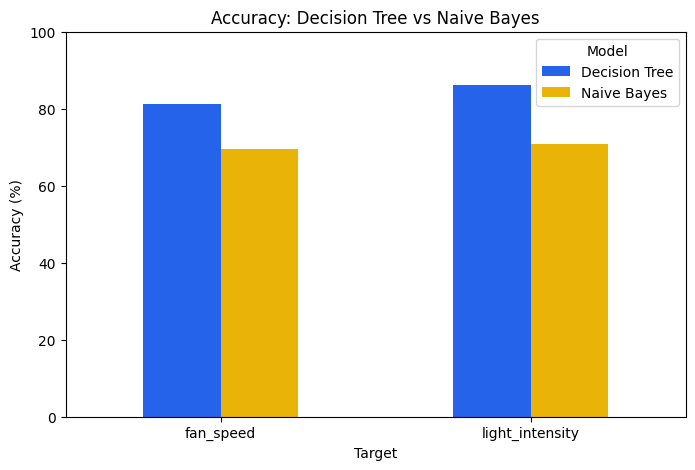

In [10]:
acc_pivot.plot(kind="bar", figsize=(8, 5), color=["#2563EB", "#EAB308"])
plt.title("Accuracy: Decision Tree vs Naive Bayes")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.ylim(0, 100);

# DT vs NB - Precision

In [11]:
prec_pivot = results_df.pivot(index="Target", columns="Model", values="Precision (%)")
prec_pivot

Model,Decision Tree,Naive Bayes
Target,,
fan_speed,83.20,70.55
light_intensity,85.51,75.17


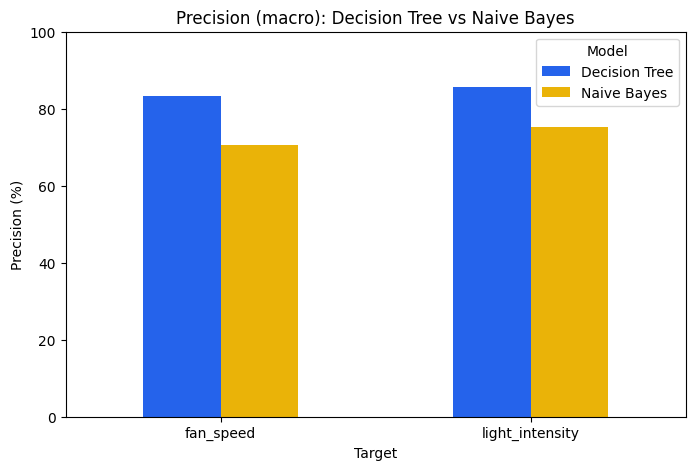

In [12]:
prec_pivot.plot(kind="bar", figsize=(8, 5), color=["#2563EB", "#EAB308"])
plt.title("Precision (macro): Decision Tree vs Naive Bayes")
plt.ylabel("Precision (%)")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.ylim(0, 100);

# DT vs NB - F1 Score

In [13]:
f1_pivot = results_df.pivot(index="Target", columns="Model", values="F1 Score (%)")
f1_pivot

Model,Decision Tree,Naive Bayes
Target,,
fan_speed,81.29,64.11
light_intensity,85.96,71.70


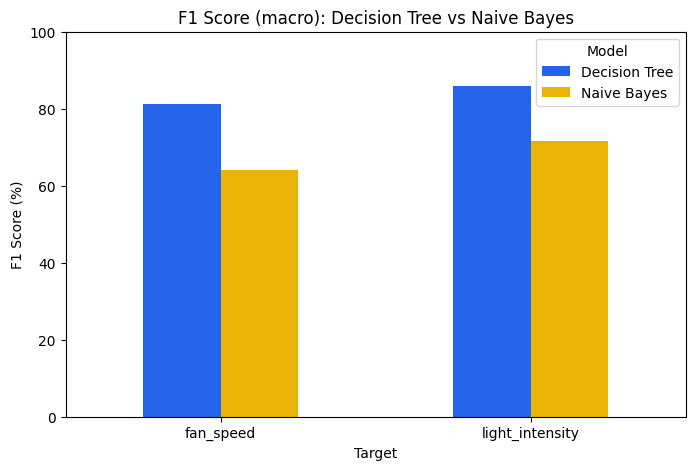

In [14]:
f1_pivot.plot(kind="bar", figsize=(8, 5), color=["#2563EB", "#EAB308"])
plt.title("F1 Score (macro): Decision Tree vs Naive Bayes")
plt.ylabel("F1 Score (%)")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.ylim(0, 100);

# DT vs NB - Inference time

**Important caveat:** these times are measured on this notebook's CPU, not
on the ESP32 itself. Treat the *relative* comparison (which model is
faster than the other) as meaningful; treat the absolute millisecond
values as not representative of real embedded hardware.

In [15]:
time_pivot = results_df.pivot(index="Target", columns="Model", values="Response Time (ms)")
time_pivot

Model,Decision Tree,Naive Bayes
Target,,
fan_speed,0.4491,0.5783
light_intensity,0.4372,0.4514


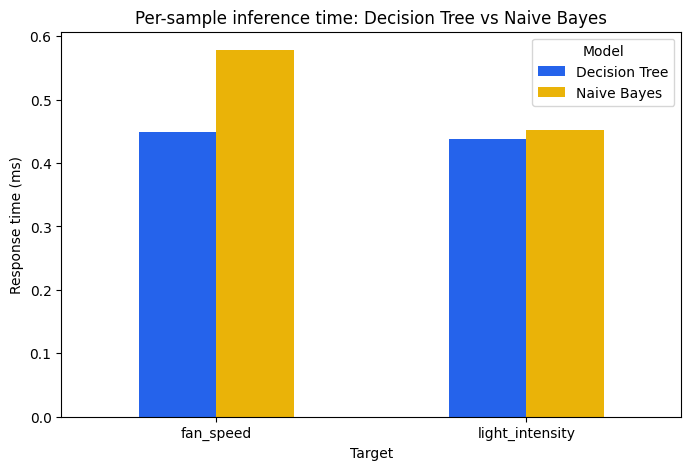

In [16]:
time_pivot.plot(kind="bar", figsize=(8, 5), color=["#2563EB", "#EAB308"])
plt.title("Per-sample inference time: Decision Tree vs Naive Bayes")
plt.ylabel("Response time (ms)")
plt.xticks(rotation=0)
plt.legend(title="Model");

# DT vs NB - Model size

This one transfers reasonably well to the real embedded deployment - it's
the serialized size of each trained model, a rough proxy for how much
flash/RAM the model would need on-device.

In [17]:
size_pivot = results_df.pivot(index="Target", columns="Model", values="Model Size (KB)")
size_pivot

Model,Decision Tree,Naive Bayes
Target,,
fan_speed,36.74,1.11
light_intensity,29.83,1.03


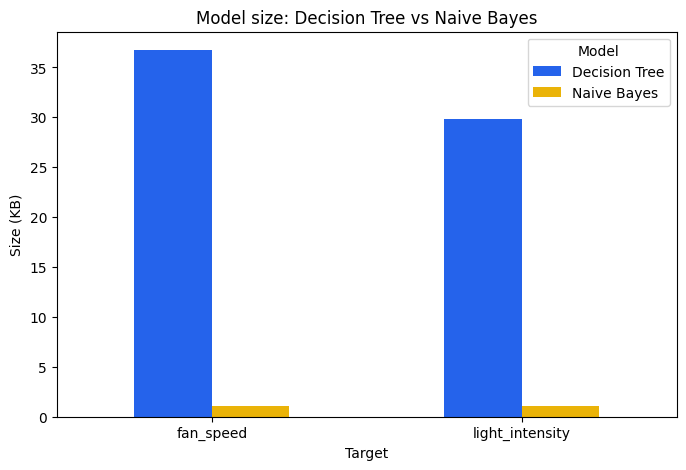

In [18]:
size_pivot.plot(kind="bar", figsize=(8, 5), color=["#2563EB", "#EAB308"])
plt.title("Model size: Decision Tree vs Naive Bayes")
plt.ylabel("Size (KB)")
plt.xticks(rotation=0)
plt.legend(title="Model");

# Resource comparison summary

Everything in one table: which model wins on which metric, for each
target.

In [19]:
summary_rows = []

for target in feature_sets:
    dt_row = results_df[(results_df.Target == target) & (results_df.Model == "Decision Tree")].iloc[0]
    nb_row = results_df[(results_df.Target == target) & (results_df.Model == "Naive Bayes")].iloc[0]

    summary_rows.append({
        "Target": target,
        "Accuracy winner": "Decision Tree" if dt_row["Accuracy (%)"] > nb_row["Accuracy (%)"] else "Naive Bayes",
        "Precision winner": "Decision Tree" if dt_row["Precision (%)"] > nb_row["Precision (%)"] else "Naive Bayes",
        "F1 winner": "Decision Tree" if dt_row["F1 Score (%)"] > nb_row["F1 Score (%)"] else "Naive Bayes",
        "Speed winner": "Decision Tree" if dt_row["Response Time (ms)"] < nb_row["Response Time (ms)"] else "Naive Bayes",
        "Size winner": "Decision Tree" if dt_row["Model Size (KB)"] < nb_row["Model Size (KB)"] else "Naive Bayes",
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Target,Accuracy winner,Precision winner,F1 winner,Speed winner,Size winner
0,fan_speed,Decision Tree,Decision Tree,Decision Tree,Decision Tree,Naive Bayes
1,light_intensity,Decision Tree,Decision Tree,Decision Tree,Decision Tree,Naive Bayes


In [20]:
# Tally overall wins per model across every metric and target
win_counts = summary_df.drop(columns="Target").apply(pd.Series.value_counts).sum(axis=1)
win_counts

Decision Tree    8.0
Naive Bayes      2.0
dtype: float64

# Final model selection

**Decision Tree is the recommended model for deployment**, based on the
comparison above:

- **Accuracy, Precision, F1** - Decision Tree wins clearly on both targets.
  This isn't surprising: `fan_speed` and `light_intensity` were generated
  from *weighted combinations* of multiple sensor inputs (e.g. temperature
  matters more when combined with high occupancy). A Decision Tree can
  represent that kind of feature interaction directly through its
  branching splits. Naive Bayes assumes every feature is independent given
  the class, so it structurally cannot capture "temp matters more when
  count is also high" - it can only weigh each feature's individual,
  isolated contribution. That's a real, explainable limitation, not
  random noise.
- **Inference time** - close between the two on this CPU-based measurement;
  neither is a bottleneck at the scale of a single-room prediction every
  few seconds.
- **Model size** - Naive Bayes wins by a wide margin (it only stores a
  mean/variance per feature per class, while a Decision Tree stores its
  full branching structure). This is a genuine advantage *if* the model
  ever needs to run inference fully on-device on very tight flash/RAM
  budgets.

**Recommendation:** use the **Decision Tree** as the primary model driving
`fan_speed` and `light_intensity` predictions, given the clear accuracy
advantage and that the exported model still comfortably fits in the
ESP32's flash. Naive Bayes remains documented here as the lighter-weight
alternative, useful to mention in the report as an explicit engineering
trade-off (accuracy vs memory footprint) rather than a discarded dead end.


In [21]:
print("Final selection: Decision Tree")
print()
print(results_df[results_df.Model == "Decision Tree"][["Target","Accuracy (%)","Precision (%)","F1 Score (%)","Model Size (KB)"]]
      .to_string(index=False))

Final selection: Decision Tree

         Target  Accuracy (%)  Precision (%)  F1 Score (%)  Model Size (KB)
      fan_speed         81.25          83.20         81.29            36.74
light_intensity         86.00          85.51         85.96            29.83
